In [79]:
import kagglehub
import os

path = kagglehub.dataset_download("uwrfkaggler/ravdess-emotional-speech-audio")

for root, dirs, files in os.walk(path):
    for filename in files:
        print(os.path.join(root, filename))

/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-08-01-01-01-02.wav
/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-01-01-01-01-02.wav
/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-07-02-01-02-02.wav
/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-07-01-01-02-02.wav
/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-01-01-02-01-02.wav
/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-06-02-02-01-02.wav
/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-04-01-02-01-02.wav
/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-01-01-01-02-02.wav
/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-02-01-01-02-02.wav
/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-03-01-01-01-02.wav
/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-07-01-02-02-02.wav
/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-05-01-01-02-02.wav
/kaggle/input/ravdess-emotional-speech-audio/Actor_0

In [98]:
your_dataset = []
for root, dirs, files in os.walk(path):
    for filename in files:
        if filename.endswith(".wav"):
            your_dataset.append(os.path.join(root, filename))

print(f"Total audio files found: {len(your_dataset)}")

Total audio files found: 2880


In [103]:
from IPython.display import Audio

Emotion: surprised


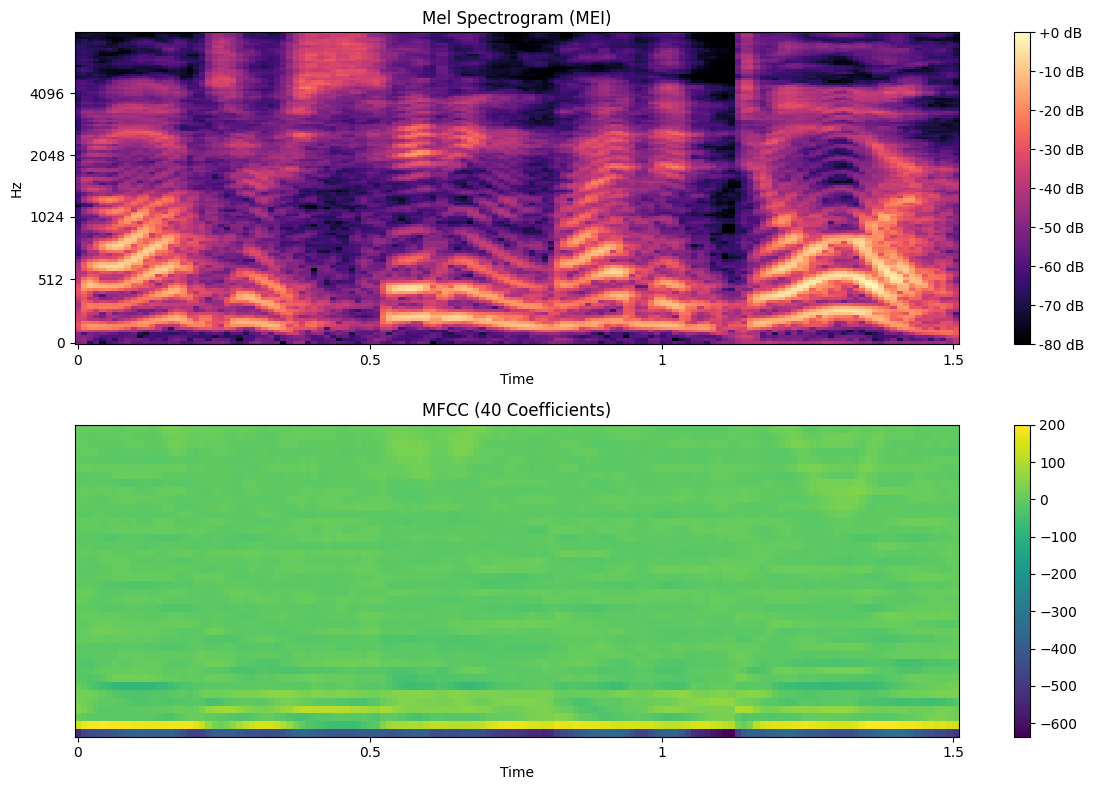

In [92]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import IPython.display as ipd
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

sample_file = os.path.join(path, "Actor_07", "03-01-08-02-02-02-07.wav")

filename = os.path.basename(sample_file)
emotion_code = int(filename.split("-")[2])

emotion_dict = {
    1: "neutral",
    2: "calm",
    3: "happy",
    4: "sad",
    5: "angry",
    6: "fearful",
    7: "disgust",
    8: "surprised"
}
y, sr = librosa.load(sample_file, sr=None)
y_trimmed, _ = librosa.effects.trim(y, top_db=20)

display(ipd.Audio(y_trimmed, rate=sr))
print("Emotion:", emotion_dict[emotion_code])

S = librosa.feature.melspectrogram(y=y_trimmed, sr=sr, n_mels=128, fmax=8000)
S_dB = librosa.power_to_db(S, ref=np.max)

mfccs = librosa.feature.mfcc(y=y_trimmed, sr=sr, n_mfcc=40)

plt.figure(figsize=(12, 8))

# Mel Spectrogram
plt.subplot(2,1,1)
librosa.display.specshow(S_dB, sr=sr, x_axis='time', y_axis='mel', fmax=8000, cmap="magma")
plt.colorbar(format='%+2.0f dB')
plt.title("Mel Spectrogram (MEI)")

plt.subplot(2,1,2)
librosa.display.specshow(mfccs, x_axis='time', sr=sr, cmap="viridis")
plt.colorbar()
plt.title("MFCC (40 Coefficients)")

plt.tight_layout()
plt.show()

In [81]:
X_all = []  # MFCC features
y_labels = []  # Emotion labels

In [82]:
dataset_path = path

# Emotion mapping
emotion_dict = {
    1: "neutral",
    2: "calm",
    3: "happy",
    4: "sad",
    5: "angry",
    6: "fearful",
    7: "disgust",
    8: "surprised"
}

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.endswith(".wav"):
            file_path = os.path.join(root, file)

            emotion_code = int(file.split("-")[2])
            y_labels.append(emotion_code)

            y, sr = librosa.load(file_path, sr=None)

            y_trimmed, _ = librosa.effects.trim(y, top_db=20)

            mfcc = librosa.feature.mfcc(y=y_trimmed, sr=sr, n_mfcc=40)

            mfcc = mfcc.T

            X_all.append(mfcc)


In [83]:
X_all_padded = pad_sequences(X_all, padding='post', dtype='float32')
print("X_all_padded shape:", X_all_padded.shape)


X_all_padded shape: (2880, 314, 40)


In [84]:
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y_labels)
y_onehot = to_categorical(y_encoded)
print("y_onehot shape:", y_onehot.shape)

y_onehot shape: (2880, 8)


In [85]:
print(y_onehot)

[[0. 0. 0. ... 0. 0. 1.]
 [1. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 1. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [86]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Masking
from sklearn.model_selection import train_test_split

In [87]:
# Split into train/test (e.g., 80/20)
X_train, X_test, y_train, y_test = train_test_split(X_all_padded, y_onehot, test_size=0.2, random_state=42)

In [88]:
time_steps = X_train.shape[1]  # padded sequence length
n_features = X_train.shape[2]  # number of MFCC coefficients (40)
n_classes = y_train.shape[1]   # number of emotions (8)

from tensorflow.keras.layers import Input

model = Sequential()
model.add(Input(shape=(time_steps, n_features)))
model.add(Masking(mask_value=0.))
model.add(LSTM(96, return_sequences=True))
model.add(Dropout(0.3))
model.add(LSTM(48))
model.add(Dropout(0.3))
model.add(Dense(n_classes, activation='softmax'))

model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

model.summary()

history = model.fit(X_train, y_train,
                    validation_data=(X_test, y_test),
                    epochs=75,
                    batch_size=32)

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking_8 (Masking)             │ (None, 314, 40)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_16 (LSTM)                  │ (None, 314, 96)        │        52,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 314, 96)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_17 (LSTM)                  │ (None, 48)             │        27,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 8)              │           392 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 80,840 (315.78 KB)

 Trainable params: 80,840 (315.78 KB)

 Non-trainable params: 0 (0.00 B)

In [89]:
history = model.fit(X_train, y_train,
                    validation_data=(X_test, y_test),
                    epochs=75,
                    batch_size=32)

Epoch 1/75
72/72 ━━━━━━━━━━━━━━━━━━━━ 35s 429ms/step - accuracy: 0.2446 - loss: 1.9635 - val_accuracy: 0.3889 - val_loss: 1.6507
Epoch 2/75
72/72 ━━━━━━━━━━━━━━━━━━━━ 31s 434ms/step - accuracy: 0.4002 - loss: 1.6010 - val_accuracy: 0.4340 - val_loss: 1.5026
Epoch 3/75
72/72 ━━━━━━━━━━━━━━━━━━━━ 42s 445ms/step - accuracy: 0.4700 - loss: 1.4368 - val_accuracy: 0.5104 - val_loss: 1.3716
Epoch 4/75
72/72 ━━━━━━━━━━━━━━━━━━━━ 31s 431ms/step - accuracy: 0.5267 - loss: 1.3080 - val_accuracy: 0.5833 - val_loss: 1.2294
Epoch 5/75
72/72 ━━━━━━━━━━━━━━━━━━━━ 41s 431ms/step - accuracy: 0.5654 - loss: 1.2152 - val_accuracy: 0.5955 - val_loss: 1.1668
Epoch 6/75
72/72 ━━━━━━━━━━━━━━━━━━━━ 44s 469ms/step - accuracy: 0.5995 - loss: 1.1108 - val_accuracy: 0.5781 - val_loss: 1.1408
Epoch 7/75
72/72 ━━━━━━━━━━━━━━━━━━━━ 39s 447ms/step - accuracy: 0.6415 - loss: 1.0286 - val_accuracy: 0.6181 - val_loss: 1.0278
Epoch 8/75
72/72 ━━━━━━━━━━━━━━━━━━━━ 40s 435ms/step - accuracy: 0.6941 - loss: 0.9002 - val_accu

In [90]:
final_train_acc = history.history['accuracy'][-1]
print(f"Train Accuracy: {final_train_acc:.4f}")
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.2f}")

Train Accuracy: 0.9809
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 150ms/step - accuracy: 0.9084 - loss: 0.3437
Test Accuracy: 0.91


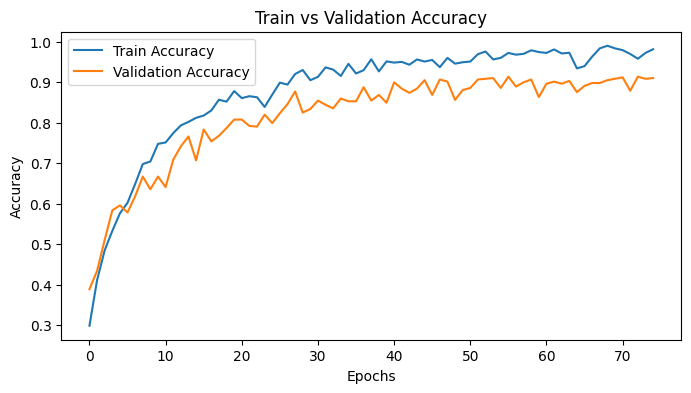

In [93]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Train vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


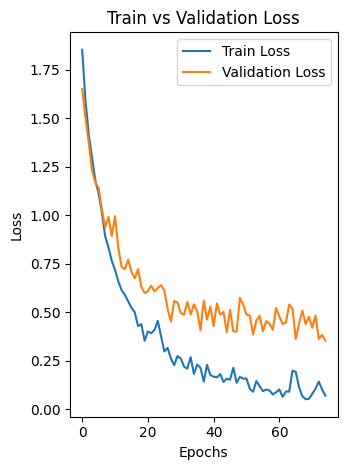

In [95]:
# Loss plot
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Train vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [97]:
model.save("emotionrecogniser.keras")

# Reload it later
from tensorflow.keras.models import load_model
model = load_model("emotionrecogniser.keras")


In [ ]:
emotion_dict = {
    1: "neutral",
    2: "calm",
    3: "happy",
    4: "sad",
    5: "angry",
    6: "fearful",
    7: "disgust",
    8: "surprised"
}

def predict_emotion(audio_path, model, time_steps, n_features):

    y, sr = librosa.load(audio_path, sr=16000)  

    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_features)
    mfcc = mfcc.T


    mfcc_padded = pad_sequences([mfcc], maxlen=time_steps, padding='post', truncating='post')

    pred = model.predict(mfcc_padded)
    emotion_idx = np.argmax(pred)

    return emotion_dict[emotion_idx], pred[0]
